
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [1]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [2]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [3]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/onnx_ops.py:159: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  tys = obj.typeStr or ''
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/skl2onnx/algebra/automation.py:154: UserWarning: OpSchema.FormalParameter.isHomogeneous is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.is_homogeneous instead.
  if getattr(obj, 'isHomogeneous', False):
/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/jinja2/environment.py:485: UserWarning: OpSchema.FormalParameter.typeStr is deprecated and will be removed in 1.16. Use OpSchema.FormalParameter.type_str instead.
  return getattr(obj, attribute)


In [4]:

import PDFshapingUtils as PDF_tk


In [5]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [6]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [7]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [8]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


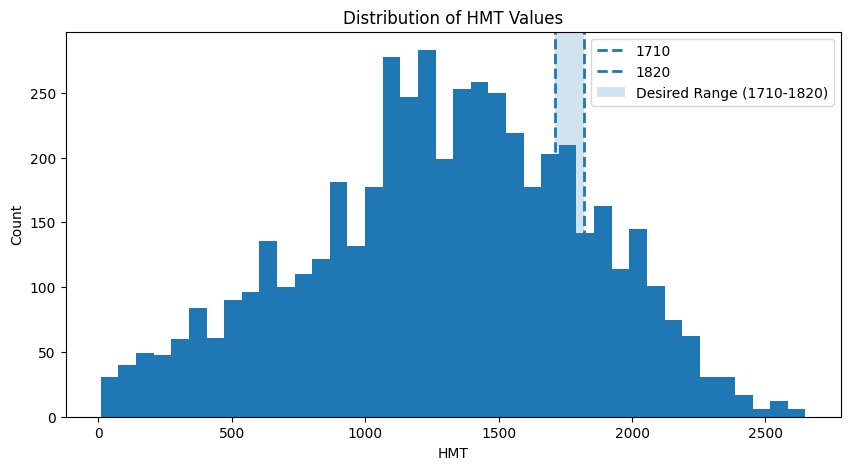

Total samples: 4999
Inside 1710-1820: 336
Percent inside: 6.72%


In [9]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

# Histogram of HMT
plt.figure(figsize=(10,5))

plt.hist(df["o_hmt"], bins=40)

# Desired operating range
plt.axvline(1710, linestyle="--", linewidth=2, label="1710")
plt.axvline(1820, linestyle="--", linewidth=2, label="1820")

# Shade target region
plt.axvspan(1710, 1820, alpha=0.2, label="Desired Range (1710-1820)")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Distribution of HMT Values")
plt.legend()

plt.show()

# Optional statistics
total = len(df)
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()

print(f"Total samples: {total}")
print(f"Inside 1710-1820: {inside}")
print(f"Percent inside: {100*inside/total:.2f}%")


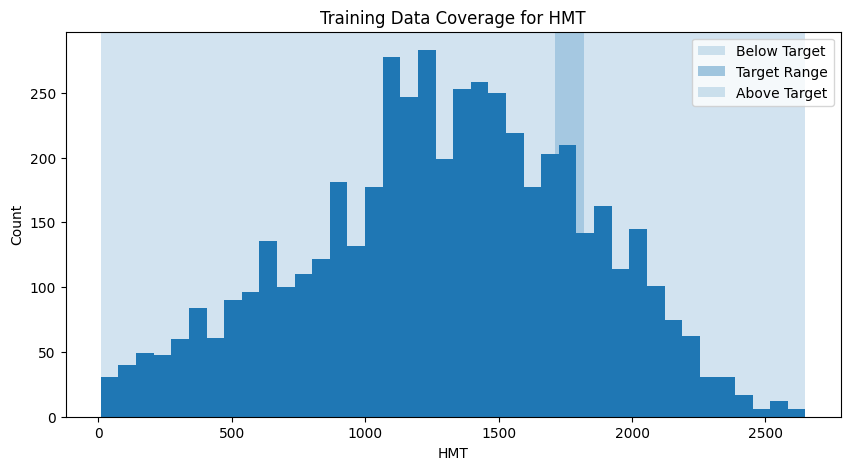

In [10]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

hmt = df["o_hmt"]

plt.figure(figsize=(10,5))
plt.hist(hmt, bins=40)

plt.axvspan(hmt.min(), 1710, alpha=0.2, label="Below Target")
plt.axvspan(1710, 1820, alpha=0.4, label="Target Range")
plt.axvspan(1820, hmt.max(), alpha=0.2, label="Above Target")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Training Data Coverage for HMT")
plt.legend()

plt.show()


In [11]:

below = (df["o_hmt"] < 1710).sum()
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()
above = (df["o_hmt"] > 1820).sum()

print("Below:", below, f"({100*below/len(df):.2f}%)")
print("Inside:", inside, f"({100*inside/len(df):.2f}%)")
print("Above:", above, f"({100*above/len(df):.2f}%)")


Below: 3830 (76.62%)
Inside: 336 (6.72%)
Above: 833 (16.66%)


In [12]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

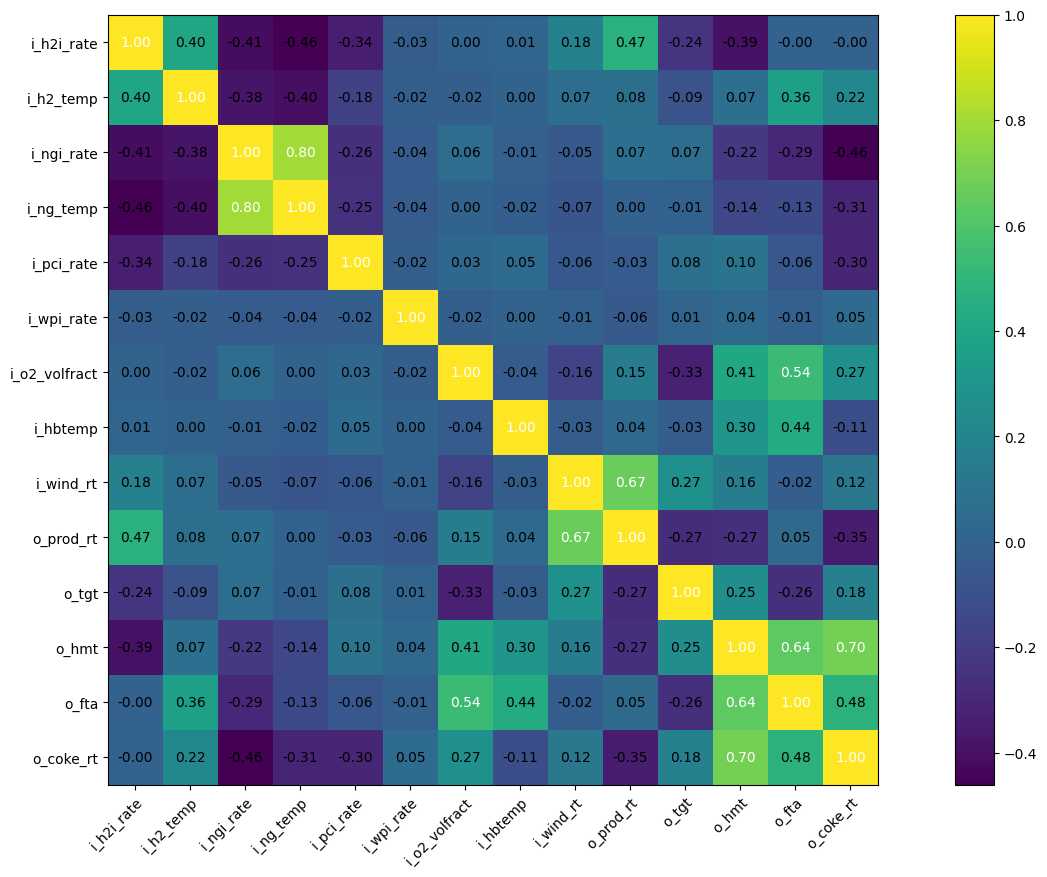

In [13]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [14]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [15]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [16]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [17]:

PDFshapingOBJ.random_seed = 42         ## int( random.random() * 100  )         ## defautl is 42


In [18]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [19]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [20]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [21]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [22]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [23]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [24]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [25]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [26]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [27]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [28]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.625618040561676
100 ..... 0.3980278968811035
200 ..... 0.2153821885585785
300 ..... 0.24622128903865814
400 ..... 0.407305508852005
500 ..... 0.24883568286895752
600 ..... 0.16742679476737976
700 ..... 0.6120333671569824
800 ..... 0.18553248047828674
900 ..... 0.18807926774024963


In [29]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.5782, 1304.0294, 8451.0449, 2310.0466,  417.2470]])
y_deviations: tensor([[  50.0365,  519.6542, 1508.7687,  210.7183,   49.7243]])
x_means: tensor([[  12.3356,   19.4929,   40.9437,   25.6174,  415.3038, 1439.6299,
          198.7547]])
x_deviations: tensor([[ 15.2321,  46.1241,  46.5318,   3.3248, 271.8232, 158.0617,  26.5062]])


In [30]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  47.5417,  784.3752, 6942.2764, 2099.3284,  367.5227]])
tensor([[ 147.6147, 1823.6836, 9959.8135, 2520.7649,  466.9713]])


In [31]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.8965,  -26.6313,   -5.5881,   22.2926,  143.4807, 1281.5681,
          172.2484]])
tensor([[  27.5676,   65.6170,   87.4755,   28.9422,  687.1270, 1597.6917,
          225.2609]])


In [32]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Costs




## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')




In [33]:



def cost_func_h2i_rate(H2_rate=10, PCI_rate=25, H2_temp=600):
    
    E22        = H2_rate
    E23        = PCI_rate
    E26        = H2_temp
    
    
    ## E22        = 10       ## Starter variable  H2 rate
    ## E23        = 25       ## Starter variable PCI rate
    ## E26        = 600      ## Starter variable H2 temp
    
    ############################
    
    E6         = 0.0143 * 0.02
    
    H6         = E6 * E26
    
    E4         = 2
    
    E5         = E4 + H6
    
    
    
    H2_ambient =  E4 * E22
    H2_heated  =  E5 * E23
    H2_temp    =  E6 * E26
    
    
    
    
    result = H2_ambient + H2_heated + H2_temp
    
    return result



cost_func_h2i_rate()



74.4616

In [34]:

## Oxygen Enrichment in Wind



def cost_func_o2_volfract( wind_rate=195, o2=0.215, prod_rate=5775):
    
    o2 = o2 / 100.0
    
    
    '''
    print("wind_rate=195")
    print("o2=0.215")
    print("prod_rate=5775")
    
    print(wind_rate)
    print(o2)
    print(prod_rate)
    '''
    
    
    E20          = wind_rate
    E25          = o2 
    E19          = prod_rate 
    
    ## E20          = 195            ## Starter variable wind rate
    ## E25          = 0.215          ## Starter variable O2 
    ## E19          = 5775           ## Starter variable production rate 
    
    ######################################
    
    H25          = (E25 - 0.21) * E20
    
    
    K25          = H25 * 60 * 24
    
    N25          = K25 / E19
    
    E9           = 0.01 * 1000
    
    result       = E9 * N25
    
    
    return result



cost_func_o2_volfract()



-101.06368831168831

In [35]:




def cost_func_pci_rate(PCI_rate=25):
    
    E23         = PCI_rate
    
    ## E23         = 25        ## Start variable PCI rate
    
    #########################
    
    E7          = 0.3
    
    result      = E7 * E23
    
    return result



cost_func_pci_rate()



7.5

In [36]:


def cost_func_ngi_rate( NG_rate=70 ):
    
    E24    = NG_rate
    
    ## E24    = 70         ## Start variable - NG rate
    
    #############################
    
    
    E8     = 0.20
    
    result = E8 * E24
    
    
    return result



cost_func_ngi_rate()


14.0

In [37]:



def cost_func_coke_rate( coke_rate=470 ):
    
    
    E21         = coke_rate
    
    ## E21         = 470      ## Start variable coke rate
    
    ########################
    

    E12         = 0.45
    
    result      = E12 * E21 
    
    return result


cost_func_coke_rate()


211.5

In [38]:



def cost_func_wind_rate( wind_rate=195, prod_rate=5775 ):
    
    
    E20       = wind_rate
    E19       = prod_rate
    
    
    ## E20       = 195         ## start variable wind rate
    ## E19       = 5775        ## start variable production rate
    
    ##########################
    

    E11       = 0.1
    
    
    H20       = E20 * 60
    K20       = H20 * 24
    
    
    N20       = K20 / E19
    
    result    = E11 * N20
    
    return result



cost_func_wind_rate()


4.862337662337662

In [39]:

def calculate_new_loss_costs_equations(x_temp, y_DEscaled):
    
    ## x_temp
    ## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    ## y_DEscaled
    ## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"
    
    
    ## print( x_temp.shape )
    ## print( y_DEscaled.shape )
    
    ##################################################################
    
    
    ## H2_rate=10, PCI_rate=25, H2_temp=600
    ## aa = cost_func_h2i_rate( x_temp[:,0], x_temp[:,1], x_temp[:,4])
    
    ##  wind_rate=195, o2=0.215, prod_rate=5775
    ## bb = cost_func_o2_volfract( x_temp[:,6], x_temp[:,3], y_DEscaled[:,2])
    
    ## PCI_rate=25
    ## cc = cost_func_pci_rate( x_temp[:,1] )
    
    ## NG_rate=70
    ## dd = cost_func_ngi_rate( x_temp[:,2] )
    
    ## coke_rate=470
    ## ee = cost_func_coke_rate( y_DEscaled[:,4] )
    
    ## wind_rate=195, prod_rate=5775
    ## ff = cost_func_wind_rate( x_temp[:,6], y_DEscaled[:,2] )
    
    ####################################################################
    
    res = 0.0  ## + aa + bb + cc + dd + ee + ff
    
    
    return res



## Now add Costs


In [40]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [41]:

def soft_box_penalty(x, lower, upper, strength=1.0):     ## strength=10.0
    
    return strength * ((torch.relu(lower - x) ** 2).sum() + (torch.relu(x - upper) ** 2).sum())


In [42]:

def soft_box_penalty2(x, lower, upper, beta=0.01):
    
    # original constraint penalty
    violation = (torch.relu(lower - x)**2 + torch.relu(x - upper)**2).sum()
    
    # NEW: center stabilizer
    center      = (lower + upper) / 2
    center_pull = ((x - center)**2).mean()
    
    return violation + beta * center_pull


In [43]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  1200,   1500, 220 ]])


get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [44]:

##                                   1710
y_clamp_min = torch.tensor([[  100,  1710,   6400,    2000,   200 ]])     ## from Ty
y_clamp_max = torch.tensor([[  150,  1820,   6600,    2600,   500 ]])


y_clamp_min_normalized =  (y_clamp_min  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
y_clamp_max_normalized =  (y_clamp_max  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


In [45]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  



In [46]:

'''

price_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


'''



'\n\nprice_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])\nprice_real    = torch.tensor(price_real, dtype=torch.float32)\n\nprice_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])\nprice_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)\n\n\n'

In [47]:


## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"


price_real    = np.array([0.0, 0.3, 0.20, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.45])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [48]:


## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [49]:

def print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main, loss_cost, loss_ranges, 
                   new_loss_costs_equations, loss_hmt_norm):
    '''
    print(f"iteration {j}")
    print(f"pred cost: {cost_pred:.2f}  " ) ## "...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
    print( "real cost:", cost_real)
    print( "                   loss_main(MSE)",     loss_main.item()        )
    print( "                       loss_ranges",    loss_ranges.item() )
    print("                      loss_hmt_norm",  loss_hmt_norm.item() )
    print( "                       loss_cost",      loss_cost.item() )
    print("                new_l_costs_equati", new_loss_costs_equations.item())
    print( "                       total loss",     loss.item()      )

    ## print( "                       loss_coke",  loss_coke.item() )
    '''
    
    ##############
    
    print(f"\nITERATION {j}")
    print("=" * 50)

    print(f"*** COSTS ***")
    print(f"Pred Cost : {cost_pred.item():10.2f}")
    print(f"Real Cost : {cost_real.item():10.2f}")

    print("\n*** LOSSES ***")

    metrics = [
        ("Loss Main (MSE)", loss_main.item()),
        ("Loss Ranges", loss_ranges.item()),
        ("Loss HMT Norm", loss_hmt_norm.item()),
        ("Loss Cost", loss_cost.item()),
        ("Cost Equation", new_loss_costs_equations),
        ("Total Loss", loss.item()),
    ]

    for name, value in metrics:
        print(f"{name:25s} {value:12.2f}")
    
    
   
 

In [50]:

PDFshapingOBJ.y_test[3]


array([   84.8,  1470. , 11500. ,  2630. ,   429. ], dtype=float32)

In [51]:



import numpy as np

Y = PDFshapingOBJ.y_test
X = PDFshapingOBJ.X_test

# y2 (HMT) is column 1
y2 = Y[:, 1]

y2_min = 1710
y2_max = 1820
y2_center = (y2_min + y2_max) / 2.0  # 1765

# Rank:
# 1. Values inside range come first
# 2. Among those, closest to center (1765) come first
# 3. Outside values come after, ordered by distance from range

score = np.where(
    (y2 >= y2_min) & (y2 <= y2_max),
    np.abs(y2 - y2_center),
    1000 + np.maximum(y2_min - y2, 0) + np.maximum(y2 - y2_max, 0)
)

idx = np.argsort(score)

X_ranked = X[idx]
Y_ranked = Y[idx]

#print(Y_ranked[:20])



PDFshapingOBJ.y_test = Y_ranked
PDFshapingOBJ.X_test = X_ranked 


In [52]:

def final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np ):
    
    print(i)
    print('*******************************************************')
    
    
    if i == 1:
        percent_errors = [ [] for _ in range(5) ]  # one list per output

    y_pred_np = wrapped_model(
                    torch.from_numpy( 
                         x_temp_pred_np
                    )).detach().numpy().flatten()
    
    y_real_np = wrapped_model(
                    torch.from_numpy(
                          x_real_np
                    )).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append( pct[k] )
    return percent_errors


In [53]:

def print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  ):
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    '''
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np[0] )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print(  PDFshapingOBJ.y_test[i]  )
    ## print( " this is a predicted y from the real x " )
    ## print( wrapped_model(torch.from_numpy(x_real_np))   )
    '''
    
    #################
    
    '''
    print(x_temp_pred_np)
    print(x_temp_pred_np.shape)
    print(x_real_np)
    print(x_real_np.shape)
    '''
    
    x_pred = np.round(x_temp_pred_np[0], 1)
    
    ##x_real = np.round(x_real_np, 1)
    x_real = np.round(x_real_np[0], 1)
    
    '''
    print(x_pred)
    print(x_pred.shape)
    print(x_real)
    print(x_real.shape)
    '''

    y_pred = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().cpu().numpy()[0]
    y_pred = np.round(y_pred, 1)
    
    ## print(y_pred)
    ## print(y_pred.shape)
    

    y_real = np.round(PDFshapingOBJ.y_test[i], 1)
    ## print(y_real)
    ## print(y_real.shape)


    print("\nINPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_x = [
        "h2i_rate","pci_rate","ngi_rate",
        "o2_volfrac","h2_temp","hbtemp","wind_rt"
    ]

    for c,p,r in zip(cols_x, x_pred, x_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")

    print("\nOUTPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_y = [
        "tgt","hmt","prod_rt","fta","coke_rt"
    ]

    for c,p,r in zip(cols_y, y_pred, y_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")


In [54]:

memory_history = []

import psutil
import os
import gc
import torch

def record_memory(i):

    ram_gb = psutil.Process(os.getpid()).memory_info().rss / 1024**3

    tensor_count = 0
    for obj in gc.get_objects():
        try:
            if torch.is_tensor(obj):
                tensor_count += 1
        except:
            pass

    memory_history.append(
        (
            i,
            ram_gb,
            tensor_count,
            len(gc.get_objects())
        )
    )


In [55]:


PDFshapingOBJ.y_test[:5]



array([[  51.9, 1760. , 7770. , 2510. ,  464. ],
       [ 210. , 1760. , 5810. , 2310. ,  500. ],
       [ 207. , 1770. , 5870. , 2330. ,  496. ],
       [ 295. , 1760. , 6710. , 2050. ,  415. ],
       [  64.2, 1760. , 7190. , 2600. ,  468. ]], dtype=float32)

In [56]:

PDFshapingOBJ.X_test[:5]


array([[   0.,    0.,   41.,   27.,  300., 1448.,  195.],
       [  10.,    0.,    0.,   21.,  300., 1480.,  195.],
       [  10.,    0.,    0.,   21.,  600., 1480.,  195.],
       [   0.,    0.,  120.,   21.,  300., 1600.,  230.],
       [  20.,    0.,    0.,   30.,  600., 1600.,  160.]], dtype=float32)

In [57]:

def calculate_real_costs_for_printing(loss_cost_descaled, x_temp_descaled, x_real, target_y):
    
    with torch.no_grad():
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = loss_cost_descaled
        ## torch.dot(price_real, x_temp_descaled.squeeze()).item()
    
        #######################
    
        x_real = x_real.unsqueeze(0)
        target_y = target_y.unsqueeze(0)
    
        ##print(x_real.shape)
        ##print(target_y.shape)
    
        loss_cost_real          =     x_real @ price_real
        loss_cost_y5_real       =   target_y @ price_real_y5
        
        loss_wind_rate_real     = cost_func_wind_rate( x_real[:, 6], target_y[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_real[:, 0], x_real[:, 1], x_real[:, 4])
        loss_o2_v    = cost_func_o2_volfract( x_real[:,6], x_real[:,3], target_y[:,2])
        
        ## loss_cost_descaled_real = loss_cost_real + loss_cost_y5_real + loss_wind_rate_real + loss_h2i_rate + loss_o2_v
    
        loss_cost_descaled_real = (
            loss_cost_real
            + loss_cost_y5_real
            + loss_wind_rate_real
            + loss_h2i_rate
            + loss_o2_v
        )
    
        #######################
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = loss_cost_descaled_real
       
    return x_temp_pred_np, x_real_np, cost_pred, cost_real


   

In [58]:

## loss_z_reg   = regularize_z(z, strength=1e-3)



In [59]:



## This may be a good one, otherwise revert to func17


def calc_dynamic_hmt_weight_func(min_y, max_y, hmt_pred, hmt_center):

    # Half-width of allowable HMT range
    scale = torch.maximum(hmt_center - min_y,
                          max_y - hmt_center)
    scale = torch.clamp(scale, min=1e-6)

    # Normalized distance from preferred HMT
    d = torch.abs(hmt_pred - hmt_center) / scale

    # Relax HMT near the center
    # 0.70 at center -> 1.00 at operating limits
    inside_weight = 0.70 + 0.30 * torch.clamp(d, max=1.0)

    # Additional penalty outside allowable range
    outside = torch.relu(min_y - hmt_pred) + \
              torch.relu(hmt_pred - max_y)

    alpha = 0.05

    outside_weight = torch.exp(alpha * outside)

    return inside_weight * outside_weight



In [60]:

coke_rate_pred_vals_for_ON_OFF = []


In [61]:

print(  PDFshapingOBJ.y_test[2].shape  )
print(  PDFshapingOBJ.X_test[2].shape  )


(5,)
(7,)


In [62]:


w_mse   = 1.0
w_cost  = 1.0       
w_range = 1.0             
w_hmt   = 120.0        ## (if can't improve, use 20 and save notebook) - 10.0   (1710)   



##############################

## Go back to this
## y_clamp_min_temp         = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]]) 

y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    
    ##############################

    hmt_history = []
    
    ##############################
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y_normalized  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    
    z_init    = torch.rand((1,7))*0.2 + 0.3
    z         = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
    
    for j in range(3000):              ## 2000
        
        optimizer.zero_grad()
        
        x_temp_descaled              = get_x_from_z(    z    )

        y_descaled, current_y_normalized = model_Forward( x_temp_descaled )
        
        ##########################################
        
        loss_main_norm   = torch.mean(  (current_y_normalized - target_y_normalized)**2  )
        
        ##########################################
        
        loss_ranges_norm = soft_box_penalty(current_y_normalized, y_clamp_min_normalized, y_clamp_max_normalized)
        
        ##########################################
        
        new_loss_costs_equations = 0.0
        
        loss_cost          =     x_temp_descaled @ price_real
        loss_cost_y5       =          y_descaled @ price_real_y5
        
        
        loss_wind_rate = cost_func_wind_rate( x_temp_descaled[:, 6], y_descaled[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_temp_descaled[:, 0], x_temp_descaled[:, 1], x_temp_descaled[:, 4])
        loss_o2_vol    = cost_func_o2_volfract( x_temp_descaled[:,6], x_temp_descaled[:,3], y_descaled[:,2])
        
        loss_cost_descaled = loss_cost + loss_cost_y5 + loss_wind_rate + loss_h2i_rate + loss_o2_vol
        
    
        ##########################################
        # HMT is index 1 (1710)
        
        ## y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
        ## y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
        
        hmt_pred         =   current_y_normalized[:, 1]
        
        
        hmt_history.append(  hmt_pred.detach()  )
        
        
        hmt_center       =   y_clamp_min_temp_normalized[:, 1]       

        loss_hmt_norm    =      ( hmt_center - hmt_pred ) ** 2
        
        
        ################################################
        
        quad_exp_weight = 1        ## zero is off, just change to 1 for on 
        
        
        if len(hmt_history) < 50:
            hmt_dynamic_avg = hmt_pred
        else:
            hmt_dynamic_avg = torch.stack(  hmt_history[-50:]  ).mean(dim=0)



        if quad_exp_weight == 0:
            dynamic_hmt_weight = 1
        else:
            dynamic_hmt_weight = calc_dynamic_hmt_weight_func( y_clamp_min_normalized[:, 1], y_clamp_max_normalized[:, 1], hmt_dynamic_avg, hmt_center )

     
        
     
        ################################################
        
        loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*dynamic_hmt_weight*loss_hmt_norm
    
        ## loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*loss_hmt_norm 
    
        loss_descaled = w_cost*loss_cost_descaled  
        
        loss = loss_norm + loss_descaled
        
    
        
        '''
        print("loss_main_norm", loss_main_norm.item() )
        print("loss_ranges_norm", loss_ranges_norm.item() )
        print("loss_hmt_norm", loss_hmt_norm.item() )
        print("loss_cost_descaled", loss_cost_descaled.item() )
        print("new_loss_costs_equations", new_loss_costs_equations.item() )
        print("loss", loss.item() )
        input()
        '''
        
    
        loss.backward()
        optimizer.step()
        
        #####################################################################
        #####################################################################
        #####################################################################
        #####################################################################
        
        '''
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = torch.dot(price_real, x_temp_descaled.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
        '''
        
        
        x_temp_pred_np, x_real_np, cost_pred, cost_real = calculate_real_costs_for_printing(loss_cost_descaled, 
                                                                          x_temp_descaled, x_real, target_y)
        
       
        if j % 400 == 0:           
            print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main_norm, 
                              loss_cost_descaled, loss_ranges_norm, new_loss_costs_equations, loss_hmt_norm)
        
   
        #####################################################################
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append( percent_diff.item() )
        
    ###################################################################################
            
    cost_diffs.append(        cost_diff.item()  )
    actual_pred_cost.append(  cost_pred.item()  )
    actual_real_cost.append(  cost_real.item()  )
      

    print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  )
    
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    
    ## percent_errors = final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np )
    print(i)
    print('*******************************************************')
    
    ##########################################
    
    record_memory(i)
    
    if i % 50 == 0:

        print("\nMEMORY EVOLUTION")
        print("i\tRAM(GB)\tTensors\tObjects")

        for row in memory_history:
            print(
                f"{row[0]}\t"
                f"{row[1]:.2f}\t"
                f"{row[2]:,}\t"
                f"{row[3]:,}"
            )

    print()
    
    ##########################################
    
    if i == 1:
        percent_errors = [[] for _ in range(5)]  # one list per output

    y_pred_np = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy().flatten()
    y_real_np = wrapped_model(torch.from_numpy(x_real_np)).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append(pct[k])
            
    
    coke_rate_pred_vals_for_ON_OFF.append(    y_pred_np[4]      )
    
    




ITERATION 0
*** COSTS ***
Pred Cost :     644.79
Real Cost :     249.92

*** LOSSES ***
Loss Main (MSE)                  23.92
Loss Ranges                      56.88
Loss HMT Norm                    18.87
Loss Cost                       644.79
Cost Equation                     0.00
Total Loss                     3524.71

ITERATION 400
*** COSTS ***
Pred Cost :     452.71
Real Cost :     249.92

*** LOSSES ***
Loss Main (MSE)                  10.24
Loss Ranges                      23.55
Loss HMT Norm                     0.01
Loss Cost                       452.71
Cost Equation                     0.00
Total Loss                      487.07

ITERATION 800
*** COSTS ***
Pred Cost :     371.27
Real Cost :     249.92

*** LOSSES ***
Loss Main (MSE)                   7.23
Loss Ranges                      13.39
Loss HMT Norm                     0.01
Loss Cost                       371.27
Cost Equation                     0.00
Total Loss                      392.93

ITERATION 1200
*** COSTS *

/Users/user/opt/anaconda3/envs/CIVS_py37/lib/python3.7/site-packages/torch/distributed/distributed_c10d.py:263: UserWarning: torch.distributed.reduce_op is deprecated, please use torch.distributed.ReduceOp instead
  "torch.distributed.reduce_op is deprecated, please use "



ITERATION 400
*** COSTS ***
Pred Cost :     545.55
Real Cost :     248.16

*** LOSSES ***
Loss Main (MSE)                  15.41
Loss Ranges                      44.50
Loss HMT Norm                     0.00
Loss Cost                       545.55
Cost Equation                     0.00
Total Loss                      605.61

ITERATION 800
*** COSTS ***
Pred Cost :     449.42
Real Cost :     248.16

*** LOSSES ***
Loss Main (MSE)                  11.38
Loss Ranges                      29.57
Loss HMT Norm                     0.00
Loss Cost                       449.42
Cost Equation                     0.00
Total Loss                      490.91

ITERATION 1200
*** COSTS ***
Pred Cost :     390.78
Real Cost :     248.16

*** LOSSES ***
Loss Main (MSE)                   8.37
Loss Ranges                      18.57
Loss HMT Norm                     0.01
Loss Cost                       390.78
Cost Equation                     0.00
Total Loss                      418.57

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     313.10
Real Cost :     282.82

*** LOSSES ***
Loss Main (MSE)                   0.84
Loss Ranges                       6.60
Loss HMT Norm                     0.02
Loss Cost                       313.10
Cost Equation                     0.00
Total Loss                      322.39

ITERATION 2000
*** COSTS ***
Pred Cost :     283.14
Real Cost :     282.82

*** LOSSES ***
Loss Main (MSE)                   0.50
Loss Ranges                       3.16
Loss HMT Norm                     0.01
Loss Cost                       283.14
Cost Equation                     0.00
Total Loss                      288.24

ITERATION 2400
*** COSTS ***
Pred Cost :     267.27
Real Cost :     282.82

*** LOSSES ***
Loss Main (MSE)                   0.32
Loss Ranges                       1.95
Loss HMT Norm                     0.01
Loss Cost                       267.27
Cost Equation                     0.00
Total Loss                      271.08

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     259.94
Real Cost :     260.48

*** LOSSES ***
Loss Main (MSE)                   4.37
Loss Ranges                       1.80
Loss HMT Norm                     0.01
Loss Cost                       259.94
Cost Equation                     0.00
Total Loss                      267.65

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               6.9        0.0
pci_rate               1.3        0.0
ngi_rate              78.3      120.0
o2_volfrac            29.8       27.0
h2_temp             1136.4      300.0
hbtemp              1485.7     1200.0
wind_rt              181.2      230.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                   75.6      247.0
hmt                 1707.5     1760.0
prod_rt             8282.3     7540.0
fta                 2640.1     2050.0
coke_rt              422.0      457.0
6
*********************************************

...


ITERATION 1600
*** COSTS ***
Pred Cost :     337.34
Real Cost :     229.32

*** LOSSES ***
Loss Main (MSE)                   8.19
Loss Ranges                      12.95
Loss HMT Norm                     0.01
Loss Cost                       337.34
Cost Equation                     0.00
Total Loss                      360.18

ITERATION 2000
*** COSTS ***
Pred Cost :     308.27
Real Cost :     229.32

*** LOSSES ***
Loss Main (MSE)                   7.41
Loss Ranges                       7.47
Loss HMT Norm                     0.01
Loss Cost                       308.27
Cost Equation                     0.00
Total Loss                      324.33

ITERATION 2400
*** COSTS ***
Pred Cost :     282.95
Real Cost :     229.32

*** LOSSES ***
Loss Main (MSE)                   7.00
Loss Ranges                       3.99
Loss HMT Norm                     0.02
Loss Cost                       282.95
Cost Equation                     0.00
Total Loss                      295.78

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     272.17
Real Cost :     231.62

*** LOSSES ***
Loss Main (MSE)                   6.06
Loss Ranges                       2.59
Loss HMT Norm                     0.01
Loss Cost                       272.17
Cost Equation                     0.00
Total Loss                      282.46

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate              11.0       30.0
pci_rate               1.7        0.0
ngi_rate              78.6       80.0
o2_volfrac            30.7       21.0
h2_temp             1095.2      300.0
hbtemp              1475.5     1200.0
wind_rt              186.7      230.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                   75.8      110.0
hmt                 1704.2       72.1
prod_rt             8734.4    11100.0
fta                 2639.3     1840.0
coke_rt              421.6      339.0
990
*******************************************


ITERATION 400
*** COSTS ***
Pred Cost :     478.34
Real Cost :     243.58

*** LOSSES ***
Loss Main (MSE)                  10.73
Loss Ranges                      38.14
Loss HMT Norm                     0.01
Loss Cost                       478.34
Cost Equation                     0.00
Total Loss                      527.79

ITERATION 800
*** COSTS ***
Pred Cost :     399.09
Real Cost :     243.58

*** LOSSES ***
Loss Main (MSE)                   8.11
Loss Ranges                      22.23
Loss HMT Norm                     0.01
Loss Cost                       399.09
Cost Equation                     0.00
Total Loss                      430.46

ITERATION 1200
*** COSTS ***
Pred Cost :     342.73
Real Cost :     243.58

*** LOSSES ***
Loss Main (MSE)                   6.41
Loss Ranges                      13.58
Loss HMT Norm                     0.01
Loss Cost                       342.73
Cost Equation                     0.00
Total Loss                      364.16

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     348.69
Real Cost :     258.32

*** LOSSES ***
Loss Main (MSE)                   6.78
Loss Ranges                      10.57
Loss HMT Norm                     0.01
Loss Cost                       348.69
Cost Equation                     0.00
Total Loss                      367.25

ITERATION 2000
*** COSTS ***
Pred Cost :     317.16
Real Cost :     258.32

*** LOSSES ***
Loss Main (MSE)                   6.34
Loss Ranges                       6.48
Loss HMT Norm                     0.01
Loss Cost                       317.16
Cost Equation                     0.00
Total Loss                      330.71

ITERATION 2400
*** COSTS ***
Pred Cost :     290.16
Real Cost :     258.32

*** LOSSES ***
Loss Main (MSE)                   5.54
Loss Ranges                       3.77
Loss HMT Norm                     0.01
Loss Cost                       290.16
Cost Equation                     0.00
Total Loss                      300.66

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     243.37
Real Cost :     199.15

*** LOSSES ***
Loss Main (MSE)                   4.82
Loss Ranges                       1.34
Loss HMT Norm                     0.01
Loss Cost                       243.37
Cost Equation                     0.00
Total Loss                      251.04

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               4.7       10.0
pci_rate               1.0        0.0
ngi_rate              58.3       60.0
o2_volfrac            26.3       21.0
h2_temp             1170.2      300.0
hbtemp              1490.1     1200.0
wind_rt              197.3      160.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                   90.6       45.5
hmt                 1707.4       20.2
prod_rt             8271.6     7060.0
fta                 2578.3     1910.0
coke_rt              428.1      364.0
997
*******************************************

In [63]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


Average Euclidean Distance of Xs:
Method A: 781.53705


In [64]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


Average Euclidean Distance of Ys:
Method A: 1345.8236


In [65]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


average cost diff: -33.888174078008674
average percent diff: 33.436515890368995 %


In [66]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


solver cheaper in: 60.86086086086087 % of cases


In [67]:

print(total)
print(better)


999
608


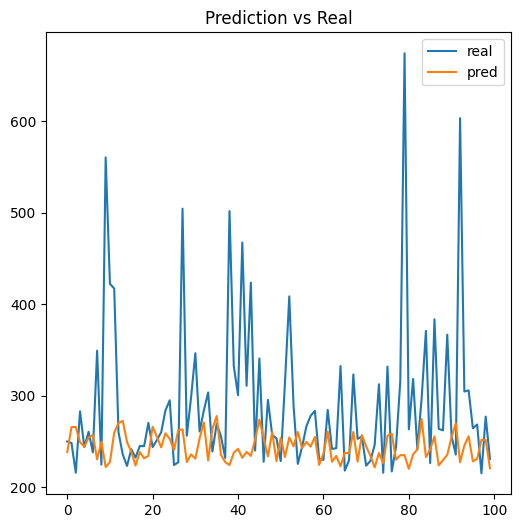

In [68]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


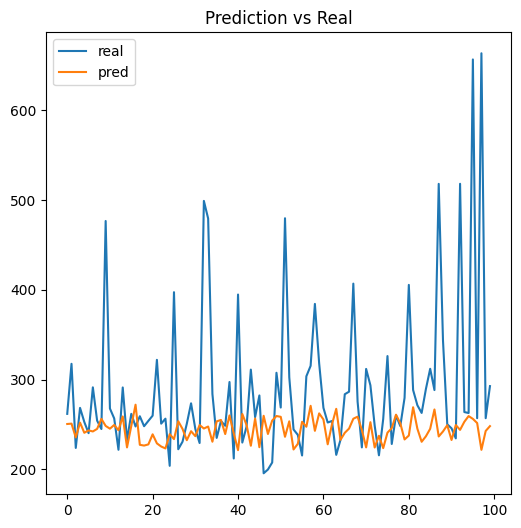

In [69]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


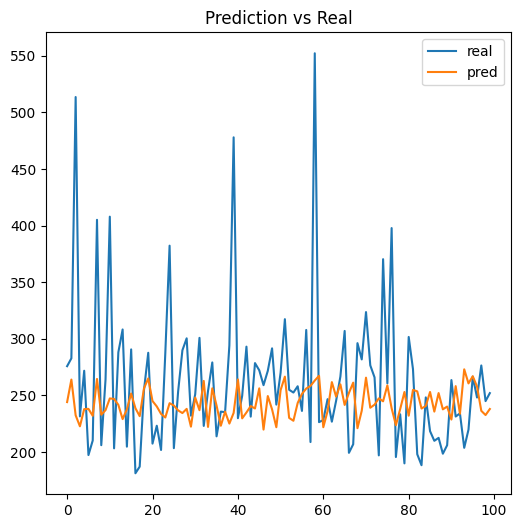

In [70]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


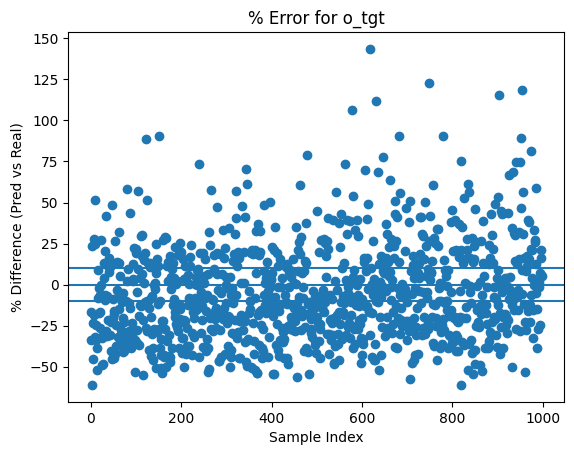

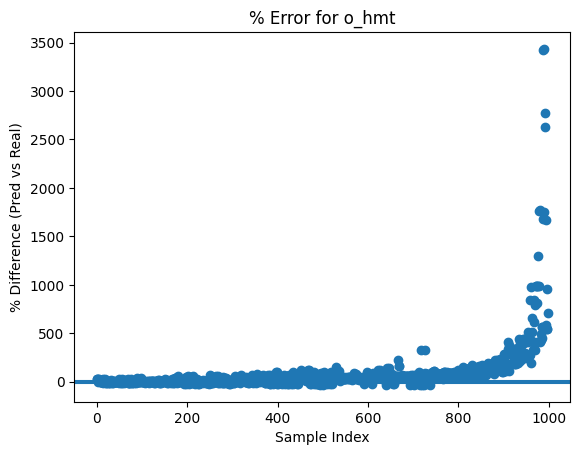

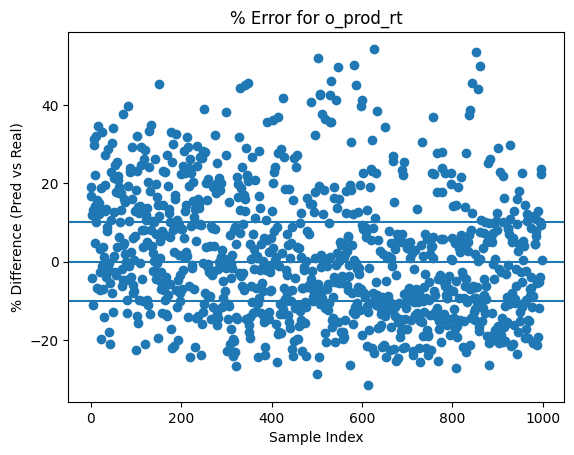

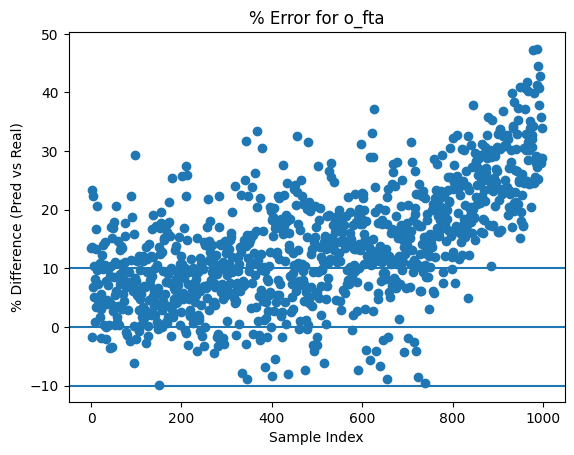

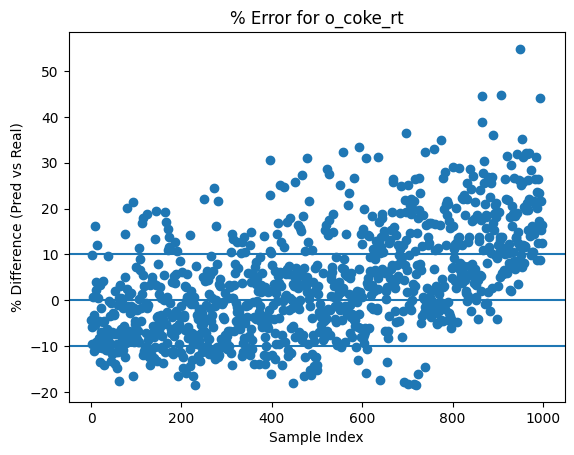

In [71]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


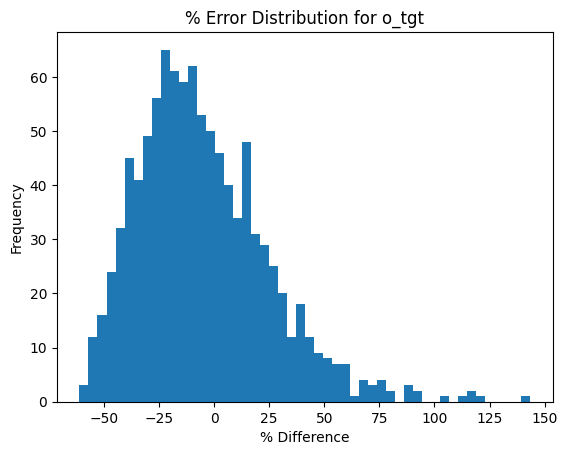

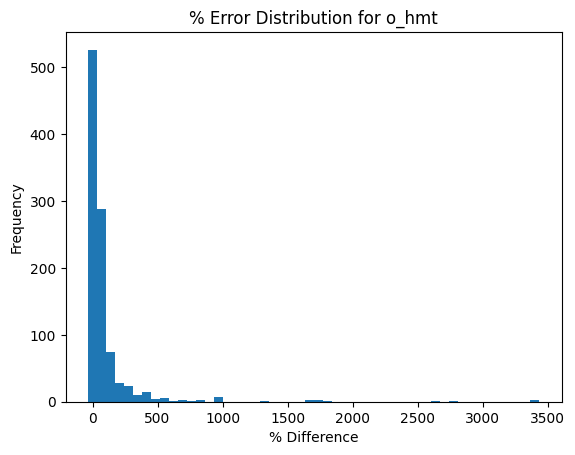

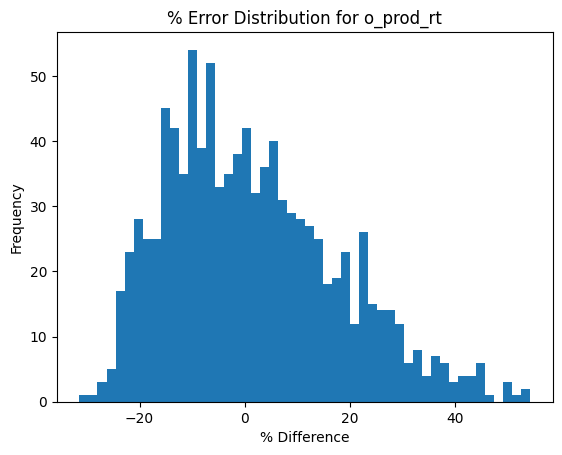

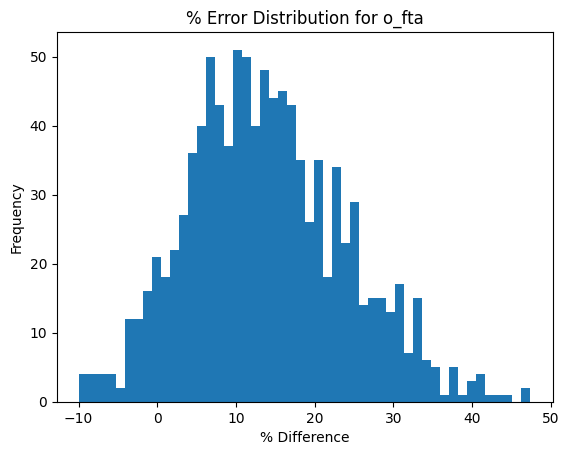

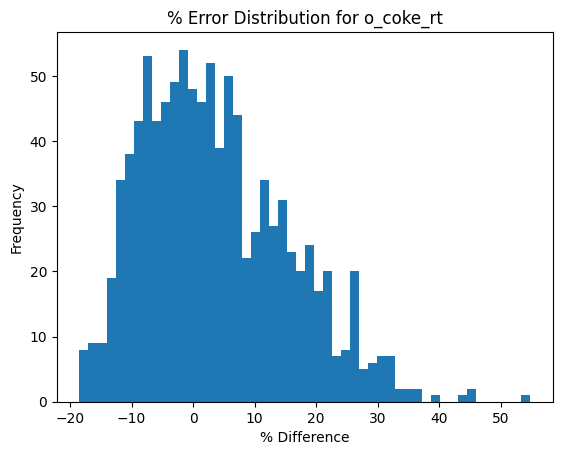

In [72]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [73]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


o_tgt
  within 5% : 11.911911911911911
  within 10%: 23.623623623623622
o_hmt
  within 5% : 11.11111111111111
  within 10%: 19.51951951951952
o_prod_rt
  within 5% : 21.12112112112112
  within 10%: 44.24424424424424
o_fta
  within 5% : 16.616616616616618
  within 10%: 37.13713713713714
o_coke_rt
  within 5% : 33.033033033033036
  within 10%: 60.56056056056056


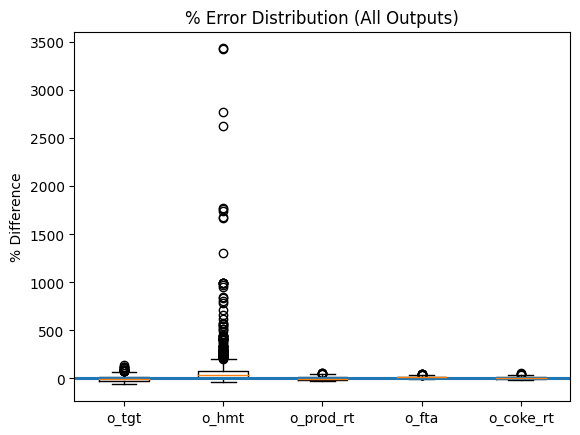

In [74]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


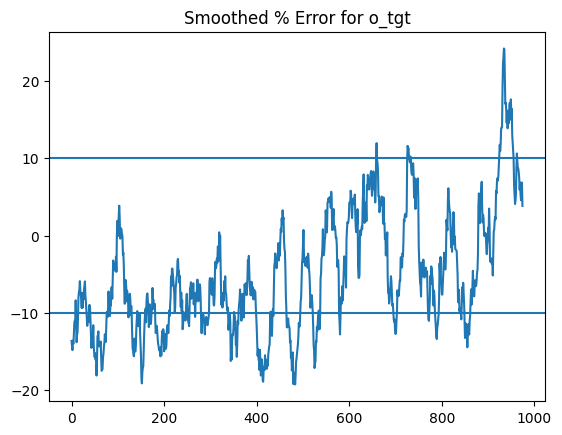

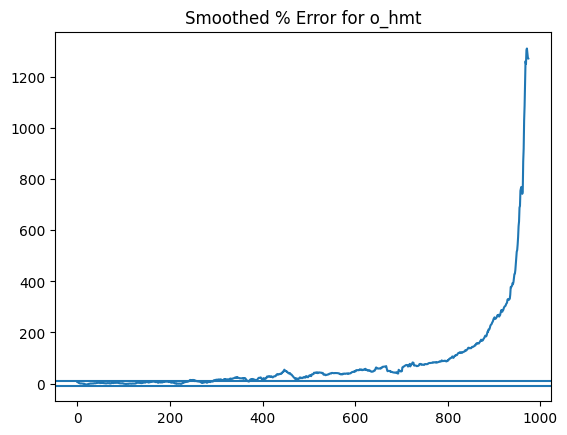

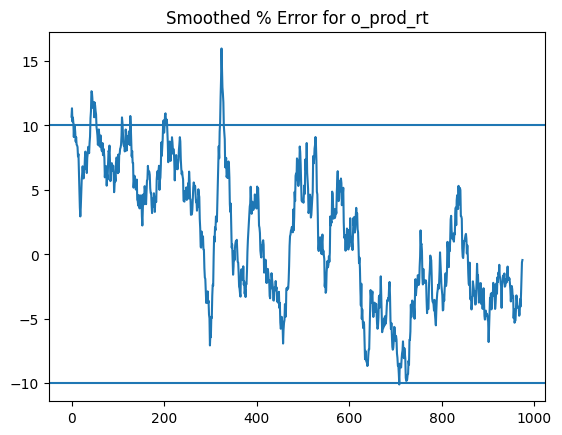

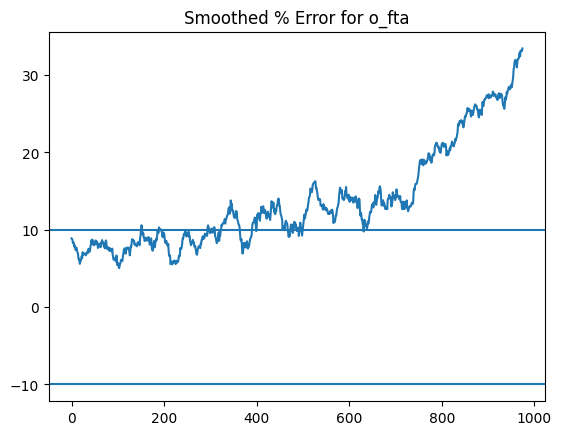

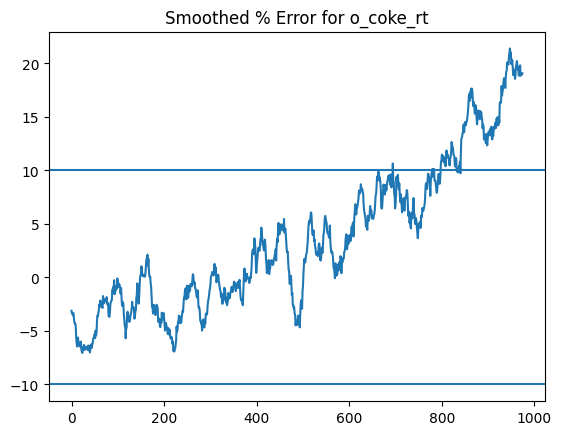

In [75]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


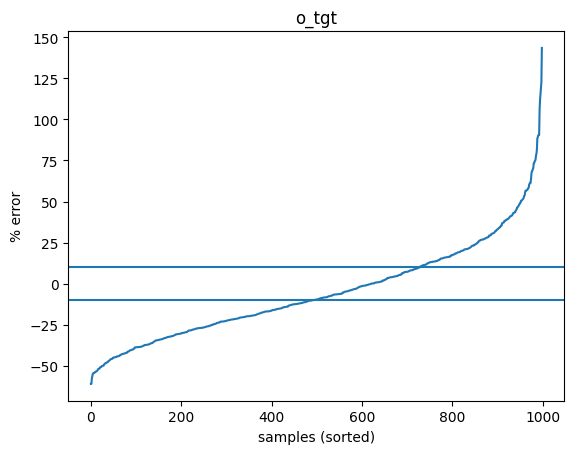

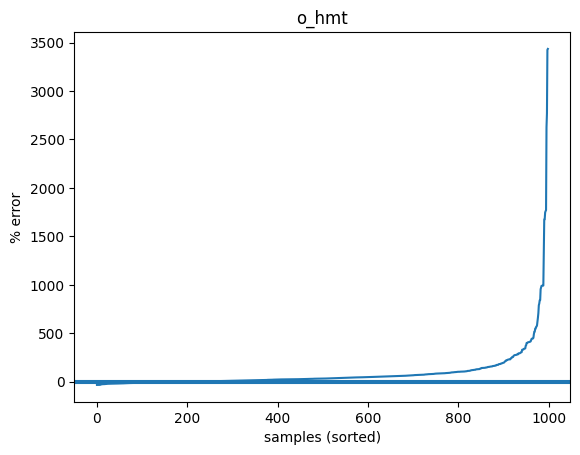

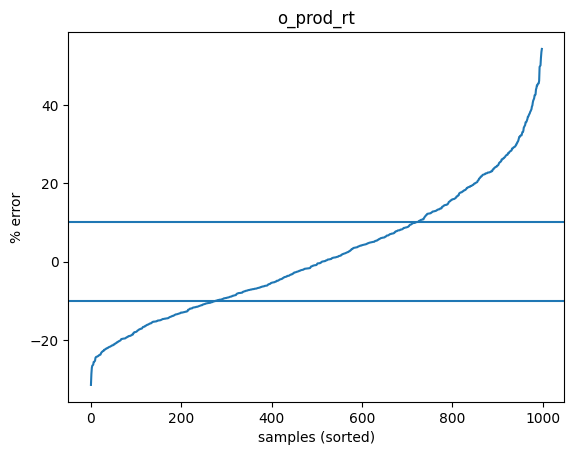

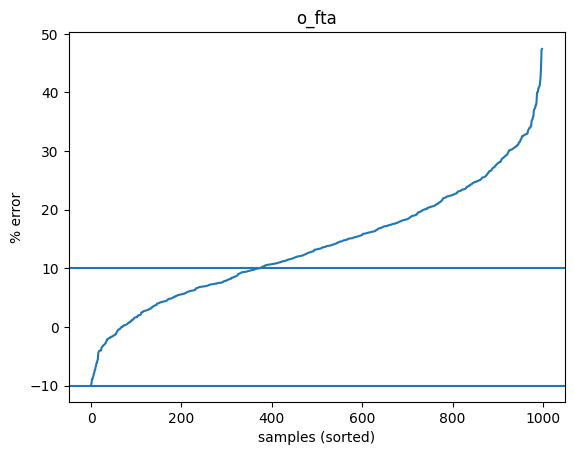

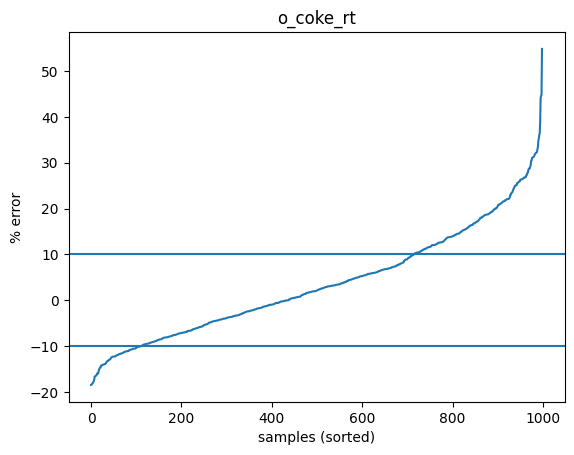

In [76]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()



## Compare effect of switch on coke rate


In [77]:

len( coke_rate_pred_vals_for_ON_OFF )


999

In [80]:

## coke_rate_pred_vals_for_ON_OFF


In [82]:

coke_rate_pred_vals_for_ON_OFF_tr = torch.tensor(coke_rate_pred_vals_for_ON_OFF)


In [86]:

mean_val = coke_rate_pred_vals_for_ON_OFF_tr.mean()

print(mean_val)



tensor(426.2705)


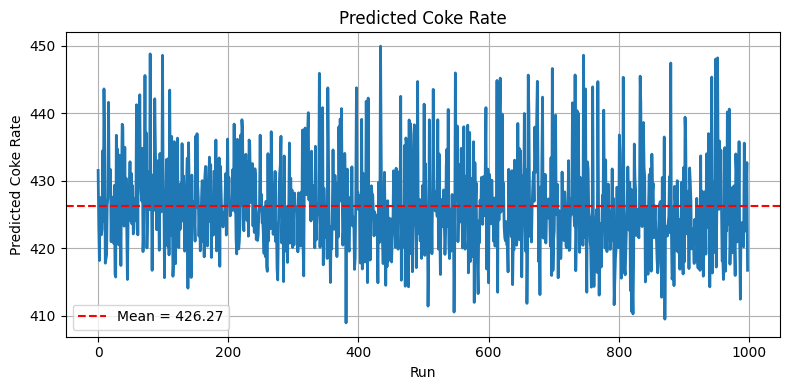

In [87]:


plt.figure(figsize=(8,4))
plt.plot(coke_rate_pred_vals_for_ON_OFF_tr.cpu().numpy(), linewidth=2)
plt.axhline(coke_rate_pred_vals_for_ON_OFF_tr.mean().item(),
            color='red', linestyle='--',
            label=f"Mean = {coke_rate_pred_vals_for_ON_OFF_tr.mean():.2f}")

plt.xlabel("Run")
plt.ylabel("Predicted Coke Rate")
plt.title("Predicted Coke Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


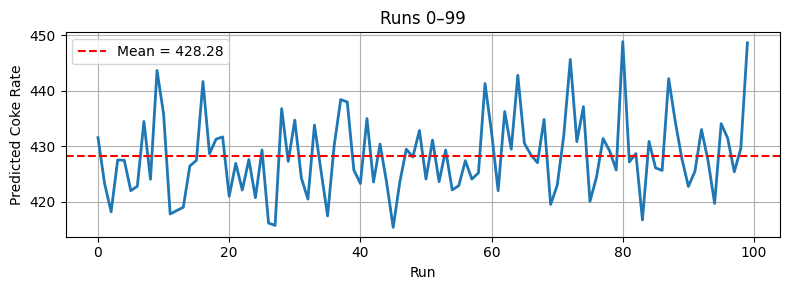

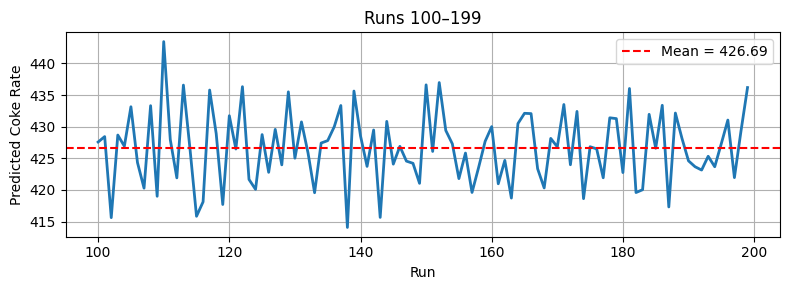

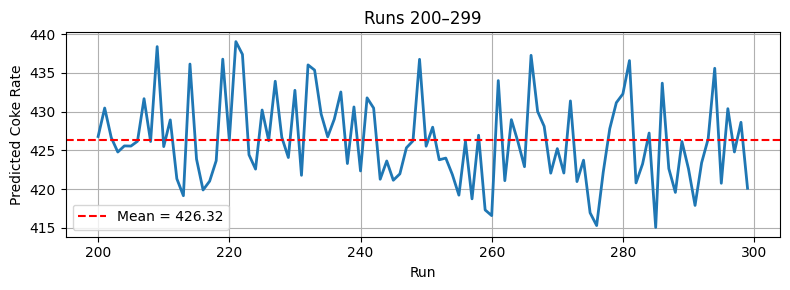

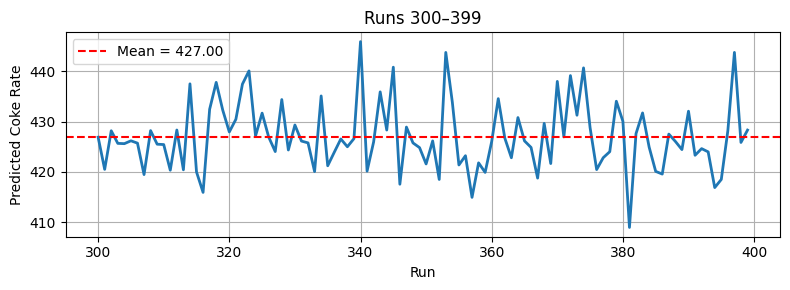

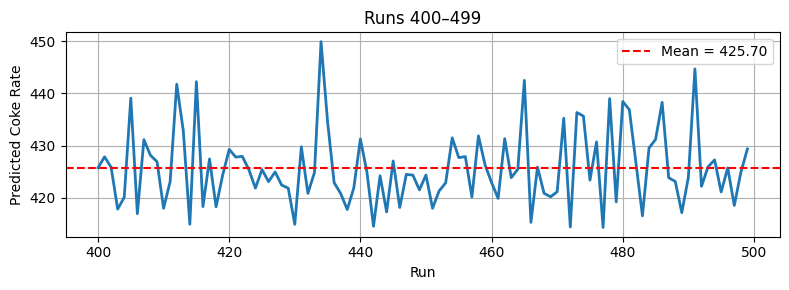

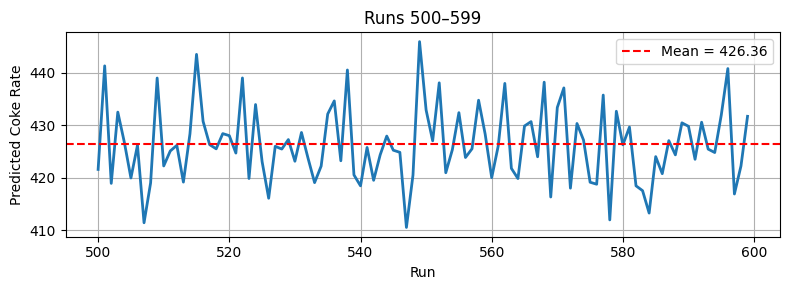

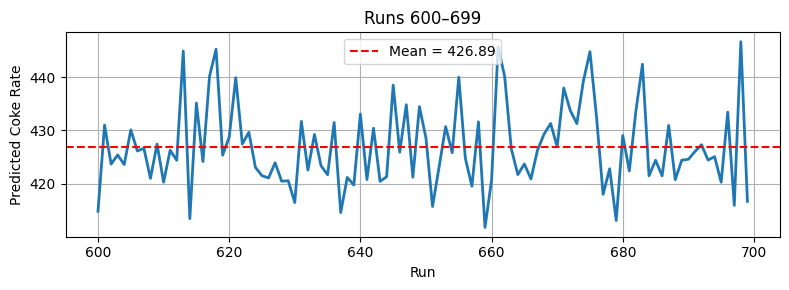

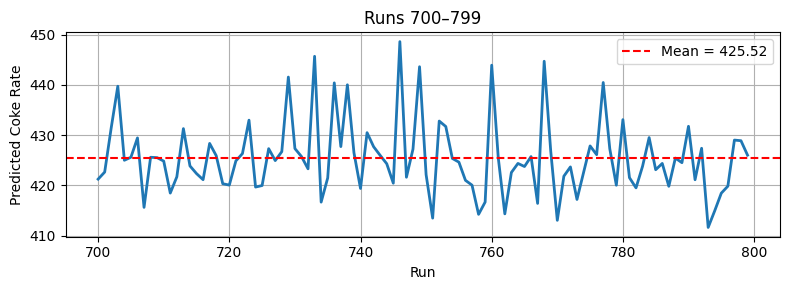

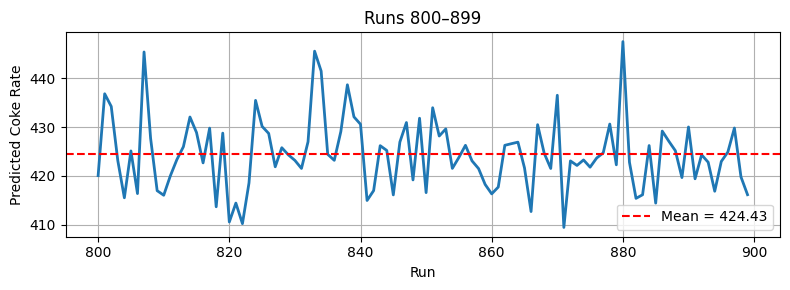

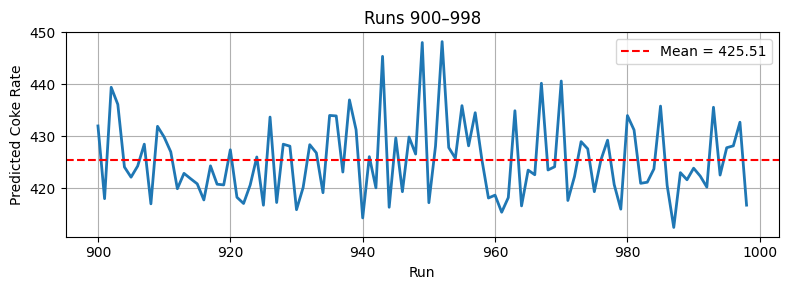

In [89]:

import matplotlib.pyplot as plt
import numpy as np

vals = coke_rate_pred_vals_for_ON_OFF_tr.cpu().numpy()

chunk_size = 100

for start in range(0, len(vals), chunk_size):
    end = min(start + chunk_size, len(vals))

    plt.figure(figsize=(8,3))
    plt.plot(np.arange(start, end), vals[start:end], linewidth=2)
    plt.axhline(vals[start:end].mean(),
                color='red', linestyle='--',
                label=f"Mean = {vals[start:end].mean():.2f}")

    plt.title(f"Runs {start}–{end-1}")
    plt.xlabel("Run")
    plt.ylabel("Predicted Coke Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


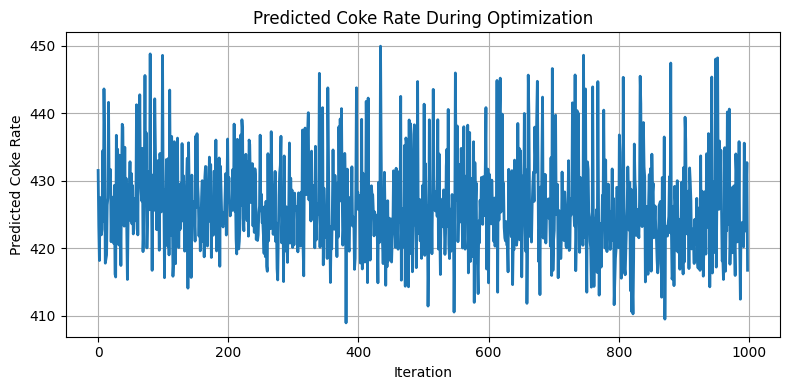

In [90]:


plt.figure(figsize=(8,4))

plt.plot(
    coke_rate_pred_vals_for_ON_OFF_tr.cpu().numpy(),
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Predicted Coke Rate")
plt.title("Predicted Coke Rate During Optimization")
plt.grid(True)

plt.tight_layout()
plt.show()


In [91]:



## torch.save(coke_rate_pred_vals_for_ON_OFF_tr.cpu(), "coke_rate_ON.pt")


## or


## torch.save(coke_rate_pred_vals_for_ON_OFF_tr.cpu(), "coke_rate_OFF.pt")



## After running OFF and ON cases, you merge data from both cases


In [ ]:

import torch
import matplotlib.pyplot as plt
import numpy as np

on  = torch.load("coke_rate_ON.pt").numpy()
off = torch.load("coke_rate_OFF.pt").numpy()

chunk_size = 100

for start in range(0, min(len(on), len(off)), chunk_size):
    end = min(start + chunk_size, len(on), len(off))

    plt.figure(figsize=(10,4))

    plt.plot(np.arange(start, end), on[start:end],
             label="Switch ON", linewidth=2)

    plt.plot(np.arange(start, end), off[start:end],
             label="Switch OFF", linewidth=2)

    plt.axhline(on[start:end].mean(),
                color='blue', linestyle='--',
                alpha=0.6,
                label=f'ON mean = {on[start:end].mean():.1f}')

    plt.axhline(off[start:end].mean(),
                color='orange', linestyle='--',
                alpha=0.6,
                label=f'OFF mean = {off[start:end].mean():.1f}')

    plt.title(f"Runs {start}–{end-1}")
    plt.xlabel("Run")
    plt.ylabel("Predicted Coke Rate")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 